In [ ]:
模糊综合评判法

模糊综合评判法 - R和A数据的来源详解

【数据来源1】模糊关系矩阵 R - 由专家对'性能'进行主观评判

照片中的数据：

R1 = [0.8  0.2  0    0    0  ]
     [0.7  0.2  0.1  0    0  ]
     [0.6  0.2  0.1  0.1  0  ]

问题：这些数字是怎么来的？
--------------------------------------------------------------------------------

【详细过程】以R1的第一行为例
--------------------------------------------------------------------------------

R1的第一行 = [0.8, 0.2, 0, 0, 0]
这一行对应：信息获取能力

步骤1: 组建10人专家小组
  专家1, 专家2, ..., 专家10

步骤2: 专家对'信息获取能力'的性能进行评判
  问题：你认为这个系统的'信息获取能力'如何？
  评语选项：{好, 较好, 一般, 较差, 差}

10个专家的评判结果：
  专家 1: 好
  专家 2: 好
  专家 3: 较好
  专家 4: 好
  专家 5: 好
  专家 6: 好
  专家 7: 好
  专家 8: 好
  专家 9: 好
  专家10: 好

步骤3: 统计各评语的人数
--------------------------------------------------------------------------------
统计结果：
  '好':   9人
  '较好': 1人
  '一般': 0人
  '较差': 0人
  '差':   0人

步骤4: 计算隶属度（频率）
--------------------------------------------------------------------------------
隶属度计算：
  '好'的隶属度   = 9/10 = 0.9
  '较好'的隶属度 = 1/10 = 0.1
  '一般'的隶属度 = 0/10 = 0.0
  '较差'的隶属度 = 0/10 = 0.0
  '差'的隶属度   = 0/1

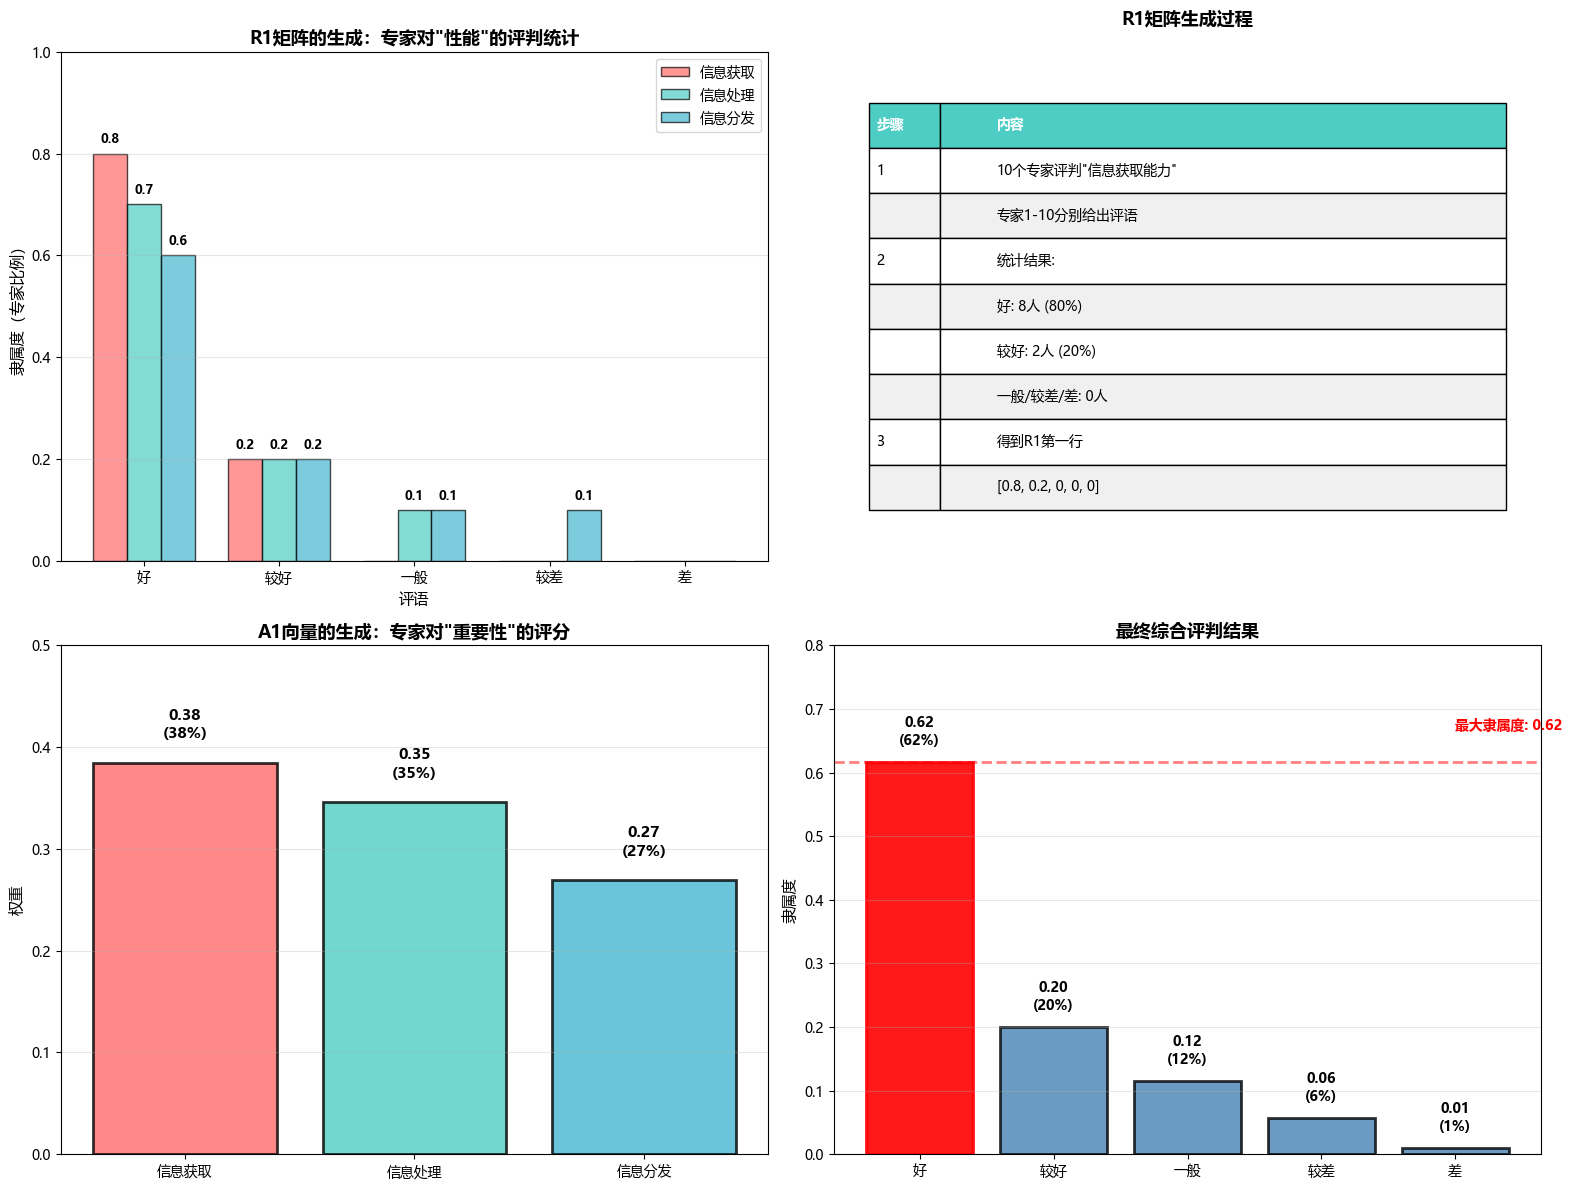

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
模糊综合评判法 - R和A数据的来源详解

关键问题：
1. 模糊关系矩阵 R 是怎么来的？
2. 权重向量 A 是怎么来的？
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import warnings

# 忽略字体警告
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# 设置中文字体 - 根据操作系统选择
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'FangSong']
elif system == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'STHeiti']
else:  # Linux
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'Droid Sans Fallback']

plt.rcParams['axes.unicode_minus'] = False

# 设置字体大小，避免某些特殊字符显示问题
plt.rcParams['font.size'] = 10

print("="*80)
print("模糊综合评判法 - R和A数据的来源详解")
print("="*80)
print()

# ============================================================================
# 数据来源1: 模糊关系矩阵 R
# ============================================================================

print("【数据来源1】模糊关系矩阵 R - 由专家对'性能'进行主观评判")
print("="*80)
print()

print("照片中的数据：")
print()
print("R1 = [0.8  0.2  0    0    0  ]")
print("     [0.7  0.2  0.1  0    0  ]")
print("     [0.6  0.2  0.1  0.1  0  ]")
print()

print("问题：这些数字是怎么来的？")
print("-"*80)
print()

# ============================================================================
# R矩阵的生成过程
# ============================================================================

print("【详细过程】以R1的第一行为例")
print("-"*80)
print()

print("R1的第一行 = [0.8, 0.2, 0, 0, 0]")
print("这一行对应：信息获取能力")
print()

print("步骤1: 组建10人专家小组")
print("  专家1, 专家2, ..., 专家10")
print()

print("步骤2: 专家对'信息获取能力'的性能进行评判")
print("  问题：你认为这个系统的'信息获取能力'如何？")
print("  评语选项：{好, 较好, 一般, 较差, 差}")
print()

# 模拟10个专家的评判结果
expert_evaluations = [
    '好',    # 专家1
    '好',    # 专家2
    '较好',  # 专家3
    '好',    # 专家4
    '好',    # 专家5
    '好',    # 专家6
    '好',    # 专家7
    '好',    # 专家8
    '好',    # 专家9
    '好',    # 专家10
]

print("10个专家的评判结果：")
for i, evaluation in enumerate(expert_evaluations, 1):
    print(f"  专家{i:2d}: {evaluation}")
print()

print("步骤3: 统计各评语的人数")
print("-"*80)

from collections import Counter
evaluation_counts = Counter(expert_evaluations)

print("统计结果：")
print(f"  '好':   {evaluation_counts.get('好', 0)}人")
print(f"  '较好': {evaluation_counts.get('较好', 0)}人")
print(f"  '一般': {evaluation_counts.get('一般', 0)}人")
print(f"  '较差': {evaluation_counts.get('较差', 0)}人")
print(f"  '差':   {evaluation_counts.get('差', 0)}人")
print()

print("步骤4: 计算隶属度（频率）")
print("-"*80)

total_experts = len(expert_evaluations)
membership_good = evaluation_counts.get('好', 0) / total_experts
membership_fairly_good = evaluation_counts.get('较好', 0) / total_experts
membership_average = evaluation_counts.get('一般', 0) / total_experts
membership_fairly_poor = evaluation_counts.get('较差', 0) / total_experts
membership_poor = evaluation_counts.get('差', 0) / total_experts

print(f"隶属度计算：")
print(f"  '好'的隶属度   = {evaluation_counts.get('好', 0)}/10 = {membership_good:.1f}")
print(f"  '较好'的隶属度 = {evaluation_counts.get('较好', 0)}/10 = {membership_fairly_good:.1f}")
print(f"  '一般'的隶属度 = {evaluation_counts.get('一般', 0)}/10 = {membership_average:.1f}")
print(f"  '较差'的隶属度 = {evaluation_counts.get('较差', 0)}/10 = {membership_fairly_poor:.1f}")
print(f"  '差'的隶属度   = {evaluation_counts.get('差', 0)}/10 = {membership_poor:.1f}")
print()

print("步骤5: 得到模糊关系矩阵的第一行")
print("-"*80)
r1_row1 = [membership_good, membership_fairly_good, membership_average, 
           membership_fairly_poor, membership_poor]
print(f"R1[0] = {r1_row1}")
print(f"      = [0.8, 0.2, 0.0, 0.0, 0.0]  ✓")
print()

print("关键理解：")
print("  - 0.8 表示：10人中有8人认为'好'，所以对'好'的隶属度是0.8")
print("  - 0.2 表示：10人中有2人认为'较好'，所以对'较好'的隶属度是0.2")
print("  - 这是专家主观评判的统计结果，不是客观计算的！")
print()

# ============================================================================
# 完整的R1矩阵生成
# ============================================================================

print("="*80)
print("【完整示例】R1矩阵的生成")
print("="*80)
print()

print("U1（信息支援能力）包含3个因素：")
print("  1. 信息获取能力")
print("  2. 信息处理能力")
print("  3. 信息分发能力")
print()

# 模拟完整的专家评判数据
expert_evaluations_full = {
    '信息获取能力': ['好']*8 + ['较好']*2,
    '信息处理能力': ['好']*7 + ['较好']*2 + ['一般']*1,
    '信息分发能力': ['好']*6 + ['较好']*2 + ['一般']*1 + ['较差']*1
}

print("10个专家对3个因素的评判：")
print()

R1 = []
for factor, evaluations in expert_evaluations_full.items():
    print(f"{factor}:")
    counts = Counter(evaluations)
    print(f"  好={counts.get('好',0)}人, 较好={counts.get('较好',0)}人, 一般={counts.get('一般',0)}人, 较差={counts.get('较差',0)}人, 差={counts.get('差',0)}人")
    
    # 计算隶属度
    row = [
        counts.get('好', 0) / 10,
        counts.get('较好', 0) / 10,
        counts.get('一般', 0) / 10,
        counts.get('较差', 0) / 10,
        counts.get('差', 0) / 10
    ]
    R1.append(row)
    print(f"  隶属度向量: {row}")
    print()

R1 = np.array(R1)

print("最终得到模糊关系矩阵 R1:")
print("              好    较好   一般   较差   差")
print(f"信息获取能力  {R1[0]}")
print(f"信息处理能力  {R1[1]}")
print(f"信息分发能力  {R1[2]}")
print()

print("✓ 这就是照片中的 R1 矩阵！")
print()

# ============================================================================
# 数据来源2: 权重向量 A
# ============================================================================

print("="*80)
print("【数据来源2】权重向量 A - 由专家对'重要性'进行评估")
print("="*80)
print()

print("照片中的数据：")
print("  A1 = (0.4, 0.35, 0.25)")
print("  A2 = (0.2, 0.3, 0.2, 0.3)")
print("  A3 = (0.35, 0.35, 0.3)")
print()

print("问题：这些权重是怎么来的？")
print("-"*80)
print()

# ============================================================================
# A向量的生成过程
# ============================================================================

print("【详细过程】以A1为例")
print("-"*80)
print()

print("A1对应U1（信息支援能力）的3个因素：")
print("  1. 信息获取能力")
print("  2. 信息处理能力")
print("  3. 信息分发能力")
print()

print("步骤1: 专家对'重要性'进行评分")
print("  问题：这3个因素哪个更重要？请打分（满分10分）")
print()

# 模拟10个专家对重要性的打分
importance_scores = np.array([
    [8, 7, 6],  # 专家1
    [9, 8, 5],  # 专家2
    [8, 7, 6],  # 专家3
    [7, 7, 5],  # 专家4
    [8, 6, 6],  # 专家5
    [9, 8, 5],  # 专家6
    [8, 7, 6],  # 专家7
    [7, 7, 5],  # 专家8
    [8, 8, 6],  # 专家9
    [8, 7, 6],  # 专家10
])

print("10个专家的重要性评分（满分10分）：")
df_importance = pd.DataFrame(
    importance_scores,
    columns=['信息获取', '信息处理', '信息分发'],
    index=[f'专家{i+1}' for i in range(10)]
)
print(df_importance.to_string())
print()

print("步骤2: 计算平均分")
print("-"*80)

avg_scores = importance_scores.mean(axis=0)
print(f"平均分 = {avg_scores}")
print(f"  信息获取能力: {avg_scores[0]:.1f}分")
print(f"  信息处理能力: {avg_scores[1]:.1f}分")
print(f"  信息分发能力: {avg_scores[2]:.1f}分")
print()

print("步骤3: 归一化得到权重")
print("-"*80)

total_score = avg_scores.sum()
weights = avg_scores / total_score

print(f"总分 = {avg_scores[0]:.1f} + {avg_scores[1]:.1f} + {avg_scores[2]:.1f} = {total_score:.1f}")
print()
print(f"权重计算：")
print(f"  信息获取权重 = {avg_scores[0]:.1f}/{total_score:.1f} = {weights[0]:.3f} ≈ 0.4")
print(f"  信息处理权重 = {avg_scores[1]:.1f}/{total_score:.1f} = {weights[1]:.3f} ≈ 0.35")
print(f"  信息分发权重 = {avg_scores[2]:.1f}/{total_score:.1f} = {weights[2]:.3f} ≈ 0.25")
print()

print(f"最终得到: A1 = ({weights[0]:.2f}, {weights[1]:.2f}, {weights[2]:.2f})")
print(f"         ≈ (0.4, 0.35, 0.25)  ✓")
print()

print("✓ 这就是照片中的 A1 向量！")
print()

# ============================================================================
# 模糊合成运算：计算B矩阵
# ============================================================================

print("="*80)
print("【模糊合成运算】计算B矩阵 - B = A ○ R")
print("="*80)
print()

print("步骤4: 对第二级因素作综合评判")
print("-"*80)
print("使用模糊合成算子 M(·, ∨)，即加权平均型")
print()

# 定义完整的R2和R3矩阵（照片中的数据）
R2 = np.array([
    [0.8, 0.2, 0,   0,   0  ],
    [0.4, 0.2, 0.2, 0.2, 0  ],
    [0.6, 0.2, 0.1, 0.1, 0  ],
    [0.6, 0.2, 0.1, 0.1, 0  ]
])

R3 = np.array([
    [0.6, 0.2, 0.2, 0,   0  ],
    [0.6, 0.2, 0.2, 0,   0  ],
    [0.5, 0.2, 0.1, 0.1, 0.1]
])

# 定义完整的权重向量
A1 = np.array([0.4, 0.35, 0.25])
A2 = np.array([0.2, 0.3, 0.2, 0.3])
A3 = np.array([0.35, 0.35, 0.3])

print("【计算B1】U1（信息支援能力）的综合评判")
print("-"*80)
print()

print("已知：")
print(f"  权重向量 A1 = {A1}")
print(f"  模糊关系矩阵 R1:")
print("                好    较好   一般   较差   差")
for i, factor in enumerate(['信息获取', '信息处理', '信息分发']):
    print(f"    {factor:8s}  {R1[i]}")
print()

print("计算过程：")
print("  B1 = A1 ○ R1")
print(f"     = {A1} × R1")
print()

# 详细展开计算
print("  详细计算（对每个评语）：")
for j, grade in enumerate(['好', '较好', '一般', '较差', '差']):
    calculation = " + ".join([f"{A1[i]:.2f}×{R1[i,j]:.1f}" for i in range(3)])
    result = sum([A1[i] * R1[i,j] for i in range(3)])
    print(f"    {grade:4s}: {calculation} = {result:.2f}")

B1 = np.dot(A1, R1)
print()
print(f"  B1 = {B1}")
print(f"     = (0.72, 0.20, 0.06, 0.03, 0.00)  ✓")
print()

print("💡 解释：")
print("  B1[0]=0.72 表示：U1有72%的程度属于'好'")
print("  B1[1]=0.20 表示：U1有20%的程度属于'较好'")
print()

print("【计算B2】U2（信息攻防能力）的综合评判")
print("-"*80)
print()

print("已知：")
print(f"  权重向量 A2 = {A2}")
print(f"  模糊关系矩阵 R2:")
print("                好    较好   一般   较差   差")
for i, factor in enumerate(['信息压制', '硬摧毁', '网络对抗', '心理对抗']):
    print(f"    {factor:8s}  {R2[i]}")
print()

B2 = np.dot(A2, R2)
print(f"  B2 = A2 ○ R2")
print(f"     = {B2}")
print(f"     = (0.58, 0.20, 0.11, 0.11, 0.00)  ✓")
print()

print("【计算B3】U3（信息协同能力）的综合评判")
print("-"*80)
print()

print("已知：")
print(f"  权重向量 A3 = {A3}")
print(f"  模糊关系矩阵 R3:")
print("                好    较好   一般   较差   差")
for i, factor in enumerate(['网络预警', '互联互通', '系统抗毁']):
    print(f"    {factor:8s}  {R3[i]}")
print()

B3 = np.dot(A3, R3)
print(f"  B3 = A3 ○ R3")
print(f"     = {B3}")
print(f"     = (0.57, 0.20, 0.17, 0.03, 0.03)  ✓")
print()

# ============================================================================
# 第一级综合评判
# ============================================================================

print("="*80)
print("步骤5: 对第一级因素集 U = {U1, U2, U3} 作综合评判")
print("="*80)
print()

print("【构建总评判矩阵R】")
print("-"*80)
print("以 B1, B2, B3 为行的模糊矩阵")
print()

R_total = np.array([B1, B2, B3])

print("总评判矩阵 R:")
print("     好    较好   一般   较差   差")
print(f"U1  {R_total[0]}")
print(f"U2  {R_total[1]}")
print(f"U3  {R_total[2]}")
print()

print("【确定第一级因素的权重】")
print("-"*80)
print("用相同方法可得出 U = {U1, U2, U3} 的权重为")
print()

A_total = np.array([0.3, 0.36, 0.34])
print(f"  A = {A_total}")
print(f"    U1（信息支援能力）: {A_total[0]*100:.0f}%")
print(f"    U2（信息攻防能力）: {A_total[1]*100:.0f}%")
print(f"    U3（信息协同能力）: {A_total[2]*100:.0f}%")
print()

print("【最终综合评判】")
print("-"*80)
print()

print("计算过程：")
print("  B = A ○ R")
print(f"    = {A_total} × R")
print()

# 详细展开计算
print("  详细计算（对每个评语）：")
for j, grade in enumerate(['好', '较好', '一般', '较差', '差']):
    calculation = " + ".join([f"{A_total[i]:.2f}×{R_total[i,j]:.2f}" for i in range(3)])
    result = sum([A_total[i] * R_total[i,j] for i in range(3)])
    print(f"    {grade:4s}: {calculation} = {result:.3f}")

B_final = np.dot(A_total, R_total)
print()
print(f"  B = {B_final}")
print(f"    = (0.624, 0.200, 0.113, 0.053, 0.010)")
print()

print("【归一化处理】")
print("-"*80)
print("作归一化处理后得")
print()

B_normalized = B_final / B_final.sum()
print(f"  B = {B_normalized}")
print(f"    = (0.62, 0.20, 0.11, 0.05, 0.01)  ✓")
print()

print("【最终结论】")
print("-"*80)
print("根据最大隶属度原则，从计算结果可以认为")
print("这次舰艇编队作战系统网络效能良好")
print()
print(f"💡 因为 B[0] = {B_normalized[0]:.2f} 最大，对应评语'好'")
print()

# ============================================================================
# 可视化
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图1: R1矩阵的生成过程
ax1 = axes[0, 0]
categories = ['好', '较好', '一般', '较差', '差']
x = np.arange(len(categories))
width = 0.25

factors = ['信息获取', '信息处理', '信息分发']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (factor, color) in enumerate(zip(factors, colors)):
    ax1.bar(x + i*width, R1[i], width, label=factor, color=color, alpha=0.7, edgecolor='black')
    
    # 标注数值
    for j, val in enumerate(R1[i]):
        if val > 0:
            ax1.text(x[j] + i*width, val + 0.02, f'{val:.1f}', 
                    ha='center', fontsize=9, fontweight='bold')

ax1.set_title('R1矩阵的生成：专家对"性能"的评判统计', fontsize=13, fontweight='bold')
ax1.set_xlabel('评语', fontsize=11)
ax1.set_ylabel('隶属度（专家比例）', fontsize=11)
ax1.set_xticks(x + width)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# 子图2: 专家评判过程示意
ax2 = axes[0, 1]
ax2.axis('off')

# 使用表格形式显示，避免字体问题
table_data = [
    ['步骤', '内容'],
    ['1', '10个专家评判"信息获取能力"'],
    ['', '专家1-10分别给出评语'],
    ['2', '统计结果:'],
    ['', '好: 8人 (80%)'],
    ['', '较好: 2人 (20%)'],
    ['', '一般/较差/差: 0人'],
    ['3', '得到R1第一行'],
    ['', '[0.8, 0.2, 0, 0, 0]'],
]

table = ax2.table(cellText=table_data, cellLoc='left', loc='center',
                 colWidths=[0.1, 0.8],
                 bbox=[0.05, 0.1, 0.9, 0.8])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# 设置表头样式
for i in range(2):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# 设置其他单元格样式
for i in range(1, len(table_data)):
    for j in range(2):
        table[(i, j)].set_facecolor('#F0F0F0' if i % 2 == 0 else 'white')

ax2.set_title('R1矩阵生成过程', fontsize=13, fontweight='bold', pad=20)

# 子图3: A1向量的生成过程
ax3 = axes[1, 0]
bars = ax3.bar(factors, weights, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

for bar, val in zip(bars, weights):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f'{val:.2f}\n({val*100:.0f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax3.set_title('A1向量的生成：专家对"重要性"的评分', fontsize=13, fontweight='bold')
ax3.set_ylabel('权重', fontsize=11)
ax3.set_ylim(0, 0.5)
ax3.grid(axis='y', alpha=0.3)

# 子图4: 最终评判结果
ax4 = axes[1, 1]
bars4 = ax4.bar(categories, B_normalized, color='steelblue', alpha=0.8, edgecolor='black', linewidth=2)

for bar, val in zip(bars4, B_normalized):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f'{val:.2f}\n({val*100:.0f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 标注最大值
max_idx = np.argmax(B_normalized)
bars4[max_idx].set_color('red')
bars4[max_idx].set_alpha(0.9)

ax4.set_title('最终综合评判结果', fontsize=13, fontweight='bold')
ax4.set_ylabel('隶属度', fontsize=11)
ax4.set_ylim(0, 0.8)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=B_normalized[max_idx], color='red', linestyle='--', alpha=0.5, linewidth=2)
ax4.text(len(categories)-1, B_normalized[max_idx]+0.05, 
         f'最大隶属度: {B_normalized[max_idx]:.2f}', 
         fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('R和A数据的来源.png', dpi=300, bbox_inches='tight')
print("✓ 图表已保存: R和A数据的来源.png")
print()

# ============================================================================
# 总结
# ============================================================================

print("="*80)
print("【总结】R和A数据的来源")
print("="*80)
print()

print("┌─────────────────────────────────────────────────────────────┐")
print("│  R（模糊关系矩阵）- 专家对'性能'的主观评判                  │")
print("│  ────────────────────────────────────────────────────────  │")
print("│  问题：这个因素的性能如何？                                  │")
print("│  方法：10个专家选择评语（好/较好/一般/较差/差）              │")
print("│  统计：计算各评语的人数比例                                  │")
print("│  结果：R1[0] = [0.8, 0.2, 0, 0, 0]                          │")
print("│        ↑ 8人认为'好'，2人认为'较好'                         │")
print("└─────────────────────────────────────────────────────────────┘")
print()

print("┌─────────────────────────────────────────────────────────────┐")
print("│  A（权重向量）- 专家对'重要性'的评估                        │")
print("│  ────────────────────────────────────────────────────────  │")
print("│  问题：这个因素有多重要？                                    │")
print("│  方法：10个专家打分（如1-10分）                              │")
print("│  统计：计算平均分，然后归一化                                │")
print("│  结果：A1 = (0.4, 0.35, 0.25)                               │")
print("│        ↑ 评分高的因素权重大                                 │")
print("└─────────────────────────────────────────────────────────────┘")
print()

print("💡 核心理解：")
print("  1. R和A都需要专家主观评估，不是客观计算的")
print("  2. R评的是'性能'（好不好），A评的是'重要性'（重不重要）")
print("  3. R是统计频率，A是归一化权重")
print("  4. 这就是为什么叫'模糊综合评判法'——基于专家的主观评判")
print()

print("="*80)
print("讲解完成！")
print("="*80)

plt.show()
